In [ ]:
### import necessary packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np

In [125]:
### import data
data= pd.read_csv("./brca_metabric_clinical_data.tsv", sep="\t")

In [126]:
### feature selection

# list of featires to keep
keep_columns=["Age at Diagnosis", 
              "Cancer Type Detailed", 
              "Inferred Menopausal State", 
              "Tumor Size",
              "Lymph nodes examined positive",
              "3-Gene classifier subtype",
              "Pam50 + Claudin-low subtype",
              "Integrative Cluster",
              "Overall Survival (Months)"]

# remove other features
data = data[keep_columns].copy()

# confirm removal
print(data.columns)

# remove sapmeles where Overall Survival is na
data = data.dropna(subset=["Overall Survival (Months)"])

Index(['Age at Diagnosis', 'Cancer Type Detailed', 'Inferred Menopausal State',
       'Tumor Size', 'Lymph nodes examined positive',
       '3-Gene classifier subtype', 'Pam50 + Claudin-low subtype',
       'Integrative Cluster', 'Overall Survival (Months)'],
      dtype='str')


In [129]:
### group rare cancer types together

top3 = data["Cancer Type Detailed"].value_counts().nlargest(3).index

data["Cancer Type Grouped"] = data["Cancer Type Detailed"].apply(
    lambda x: x if x in top3 else "Other")

print(data["Cancer Type Grouped"].value_counts())

Cancer Type Grouped
Breast Invasive Ductal Carcinoma             1538
Breast Mixed Ductal and Lobular Carcinoma     211
Breast Invasive Lobular Carcinoma             146
Other                                          86
Name: count, dtype: int64


In [39]:
### Version 1a
### discretize overall survival (months) into 3 equal grouops
data["Target1a"], bins = pd.qcut(data["Overall Survival (Months)"],
                                q=3,
                                labels=["0-6.73 years", 
                                        "6.73-13.17 years", 
                                        "13.17+ years"],
                                retbins=True)


print(bins)


[  0.          80.73333333 158.03333333 355.2       ]


In [40]:
### Version 1b
### discretize overall survival (months) into 3 groups

for index, row in data.iterrows():
    if row["Overall Survival (Months)"]>=156:
        data.loc[index, "Target1b"] = "13+ years"
    elif row["Overall Survival (Months)"]>=84:
        data.loc[index, "Target1b"] = "7-13 years"
    else:
        data.loc[index, "Target1b"] = "<7 years"


In [45]:
### Version 2a
### discretize overall survival (months) into 4 equal groups
data["Target2a"], bins = pd.qcut(data["Overall Survival (Months)"],
                                q=4,
                                labels=["0-5.07 years", 
                                        "5.07-9.71 years", 
                                        "9.71-15.43 years", 
                                        "15.43+ years"],
                                retbins=True)


print(bins)


[  0.          60.86666667 116.46666667 185.13333333 355.2       ]


In [130]:
### Version 2b
### discretize overall survival (months) into 4 groups

for index, row in data.iterrows():
    if row["Overall Survival (Months)"]>=180:
        data.loc[index, "Target2b"] = "15+ years"
    elif row["Overall Survival (Months)"]>=120:
        data.loc[index, "Target2b"] = "10-15 years"
    elif row["Overall Survival (Months)"]>=60:
        data.loc[index, "Target2b"] = "5-10 years"
    else:
        data.loc[index, "Target2b"] = "<5 years"

In [46]:
### Version 3a
### discretize overall survival (months) into 5 equal groups
data["Target3a"], bins = pd.qcut(data["Overall Survival (Months)"],
                                q=5,
                                labels=["0-4.11 years", 
                                        "4.11-7.89 years", 
                                        "7.89-11.69 years", 
                                        "11.69-16.47 years",
                                        "16.47+ years"],
                                retbins=True)


print(bins)

[  0.          49.3         94.7        140.23333333 197.66666667
 355.2       ]


In [47]:
### Version 3b
### discretize overall survival (months) into 5 groups

for index, row in data.iterrows():
    if row["Overall Survival (Months)"]>=198.5:
        data.loc[index, "Target3b"] = "16.5+ years"
    elif row["Overall Survival (Months)"]>=144:
        data.loc[index, "Target3b"] = "12-16.5 years"
    elif row["Overall Survival (Months)"]>=96:
        data.loc[index, "Target3b"] = "8-12 years"
    elif row["Overall Survival (Months)"]>=48:
        data.loc[index, "Target3b"] = "4-7 years"
    else:
        data.loc[index, "Target3b"] = "<4 years"

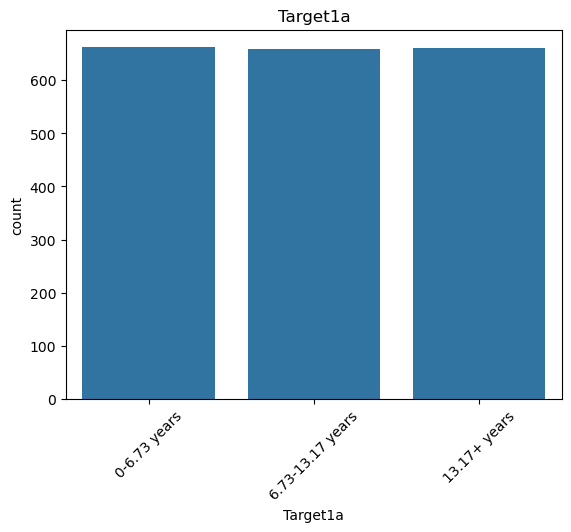

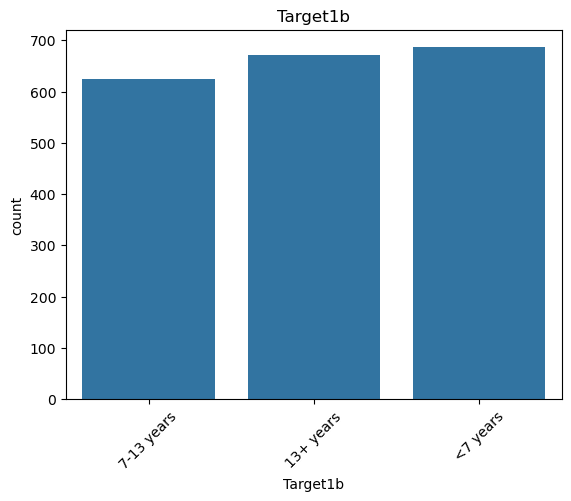

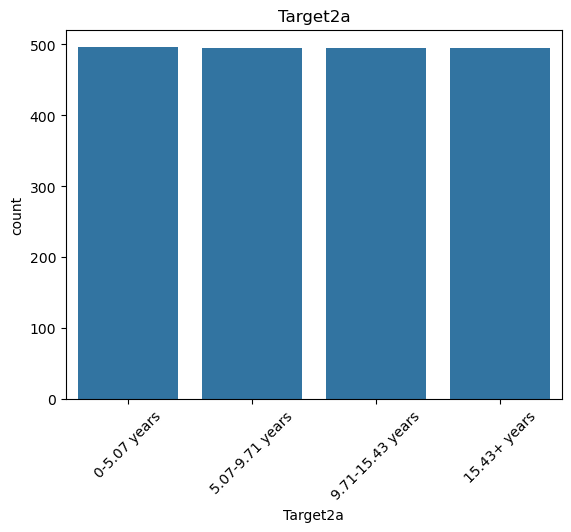

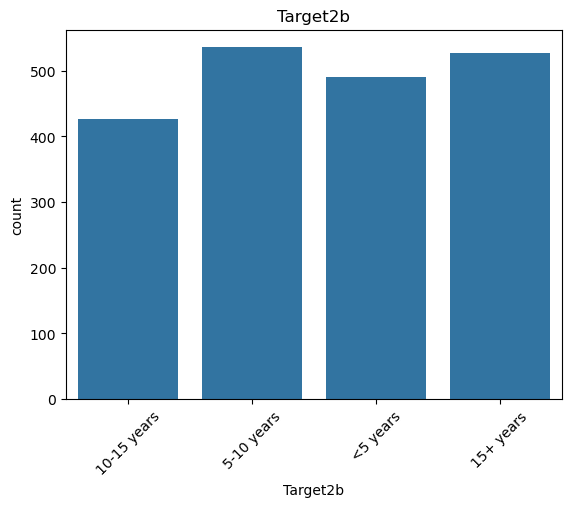

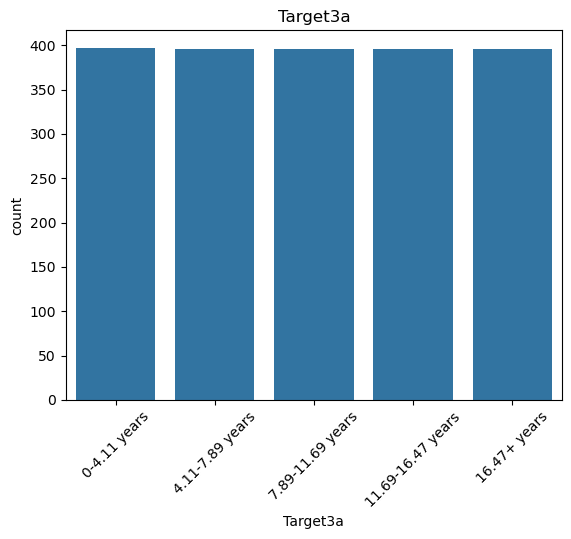

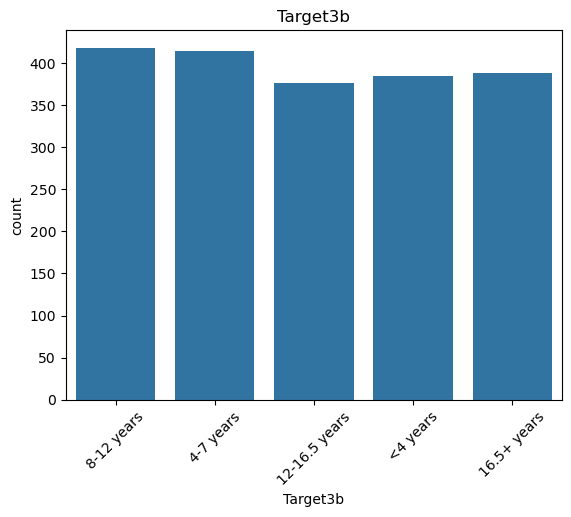

In [50]:
### check distributions

# Target1a
sns.countplot(data, x="Target1a")
plt.title('Target1a')
plt.xticks(rotation=45)
plt.show()

# Target1b
sns.countplot(data, x="Target1b")
plt.title('Target1b')
plt.xticks(rotation=45)
plt.show()

# Target2a
sns.countplot(data, x="Target2a")
plt.title('Target2a')
plt.xticks(rotation=45)
plt.show()

# Target2b
sns.countplot(data, x="Target2b")
plt.title('Target2b')
plt.xticks(rotation=45)
plt.show()

# Target3a
sns.countplot(data, x="Target3a")
plt.title('Target3a')
plt.xticks(rotation=45)
plt.show()

# Target3b
sns.countplot(data, x="Target3b")
plt.title('Target3b')
plt.xticks(rotation=45)
plt.show()

In [131]:
### split predictors and response

predictors=["Age at Diagnosis", 
              "Cancer Type Grouped", 
              "Inferred Menopausal State", 
              "Tumor Size",
              "Lymph nodes examined positive",
              "3-Gene classifier subtype",
              "Pam50 + Claudin-low subtype",
              "Integrative Cluster"]

x= data[predictors]
y=data["Target2b"]

In [133]:
### split into test and train data 
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    stratify=x["Cancer Type Grouped"],
    random_state=42)

In [134]:
### impute missing predictor values

# check NaNs
print(x_train.isna().sum())
print(x_test.isna().sum())

# impute menopausal status based on age
mask = x_test["Inferred Menopausal State"].isna()
x_test.loc[mask, "Inferred Menopausal State"] = np.where(
    x_test.loc[mask, "Age at Diagnosis"] < 52,
    "Pre",
    "Post")

# impute tumor size from training median
tumor_size_median = x_train["Tumor Size"].median()
x_train["Tumor Size"] = x_train["Tumor Size"].fillna(tumor_size_median)
x_test["Tumor Size"] = x_test["Tumor Size"].fillna(tumor_size_median)

# impute lymph nodes from training median
lymph_node_median = x_train["Lymph nodes examined positive"].median()
x_train["Lymph nodes examined positive"] = x_train["Lymph nodes examined positive"].fillna(lymph_node_median)
x_test["Lymph nodes examined positive"] = x_test["Lymph nodes examined positive"].fillna(lymph_node_median)

# impute 3-gene classifier using training mode
three_gene_mode = x_train["3-Gene classifier subtype"].mode()[0]
x_train["3-Gene classifier subtype"] = x_train["3-Gene classifier subtype"].fillna(three_gene_mode)
x_test["3-Gene classifier subtype"] = x_test["3-Gene classifier subtype"].fillna(three_gene_mode)

# impute Pam50 using training mode
pam50_mode = x_train["Pam50 + Claudin-low subtype"].mode()[0]
x_train["Pam50 + Claudin-low subtype"] = x_train["Pam50 + Claudin-low subtype"].fillna(pam50_mode)
x_test["Pam50 + Claudin-low subtype"] = x_test["Pam50 + Claudin-low subtype"].fillna(pam50_mode)

# impute IntCluster using training mode
int_cluster_mode = x_train["Integrative Cluster"].mode()[0]
x_train["Integrative Cluster"] = x_train["Integrative Cluster"].fillna(int_cluster_mode)
x_test["Integrative Cluster"] = x_test["Integrative Cluster"].fillna(int_cluster_mode)


# confirm NaNs are removed
print(x_train.isna().sum())
print(x_test.isna().sum())

Age at Diagnosis                   0
Cancer Type Grouped                0
Inferred Menopausal State          1
Tumor Size                        17
Lymph nodes examined positive     60
3-Gene classifier subtype        169
Pam50 + Claudin-low subtype        1
Integrative Cluster                1
dtype: int64
Age at Diagnosis                  0
Cancer Type Grouped               0
Inferred Menopausal State         0
Tumor Size                        9
Lymph nodes examined positive    16
3-Gene classifier subtype        48
Pam50 + Claudin-low subtype       0
Integrative Cluster               0
dtype: int64
Age at Diagnosis                 0
Cancer Type Grouped              0
Inferred Menopausal State        1
Tumor Size                       0
Lymph nodes examined positive    0
3-Gene classifier subtype        0
Pam50 + Claudin-low subtype      0
Integrative Cluster              0
dtype: int64
Age at Diagnosis                 0
Cancer Type Grouped              0
Inferred Menopausal State  

In [136]:
### seperate x train and x test for each model

# model 1- baseline
x1=["Age at Diagnosis", 
    "Cancer Type Grouped", 
    "Inferred Menopausal State", 
    "Tumor Size",
    "Lymph nodes examined positive"]
x1_train= x_train[x1]
x1_test= x_test[x1]

# model 2- baseline + 3-gene
x2= x1 + ["3-Gene classifier subtype"]
x2_train= x_train[x2]
x2_test= x_test[x2]

# model 3- baseline + Pam 50
x3= x1 + ["Pam50 + Claudin-low subtype"]
x3_train= x_train[x3]
x3_test= x_test[x3]

# model 4 - baseline + integrative clusters
x4= x1 + ["Integrative Cluster"]
x4_train= x_train[x4]
x4_test= x_test[x4]



In [137]:
### One hot encode

x1_train = pd.get_dummies(x1_train)
x1_test = pd.get_dummies(x1_test)

x2_train = pd.get_dummies(x2_train)
x2_test = pd.get_dummies(x2_test)

x3_train = pd.get_dummies(x3_train)
x3_test = pd.get_dummies(x3_test)

x4_train = pd.get_dummies(x4_train)
x4_test = pd.get_dummies(x4_test)

In [144]:
### save datasets
x1_train.to_csv("./x1_train.csv", index=False)
x1_test.to_csv("./x1_test.csv", index=False)

x2_train.to_csv("./x2_train.csv", index=False)
x2_test.to_csv("./x2_test.csv", index=False)\

x3_train.to_csv("./x3_train.csv", index=False)
x3_test.to_csv("./x3_test.csv", index=False)

x4_train.to_csv("./x4_train.csv", index=False)
x4_test.to_csv("./x4_test.csv", index=False)

y_train.to_csv("./y_train.csv", index=False)
y_test.to_csv("./y_test.csv", index=False)